In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_trop = pd.read_csv('training_log_tropical_shortest_path.csv')
df_trop.head() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,tropical,1,0.863678,0.592379,0.984808,0.439801,0.442442,0.441118,3.343284,0.095522,3.238807,26.075264,True,8.309613
1,tropical,2,0.583084,0.531959,0.985080,0.449751,0.452452,0.451098,3.283582,0.098507,4.905769,20.984070,True,7.871657
2,tropical,3,0.558268,0.524513,0.985161,0.452736,0.455455,0.454092,3.265672,0.110448,5.748061,35.480854,True,7.924734
3,tropical,4,0.553296,0.521570,0.985270,0.456716,0.459459,0.458084,3.241791,0.113433,6.663292,49.384415,True,7.912046
4,tropical,5,0.547711,0.509776,0.985351,0.459701,0.462462,0.461078,3.223881,0.113433,6.068638,36.565144,True,7.957974


In [5]:
df_trans = pd.read_csv('training_log_transformer_shortest_path.csv')
df_trans.head() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,transformer,1,0.830733,0.744621,0.984103,0.413930,0.416416,0.415170,3.498507,0.080597,1.897015,9.197177,True,4.429273
1,transformer,2,0.680533,0.720094,0.984374,0.423881,0.426426,0.425150,3.438806,0.086567,2.181693,9.982765,True,3.982566
2,transformer,3,0.665727,0.716386,0.984293,0.420896,0.423423,0.422156,3.456716,0.086567,2.267446,12.334555,True,3.987283
3,transformer,4,0.661383,0.718153,0.984537,0.429851,0.432432,0.431138,3.402985,0.092537,2.406983,11.258013,False,4.027266
4,transformer,5,0.655173,0.719257,0.984619,0.432836,0.435435,0.434132,3.385075,0.104478,2.290660,8.138096,False,3.986073


In [7]:
df_edge = pd.read_csv('training_log_edge_transformer_shortest_path.csv')
df_edge.head() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,edge_transformer,1,0.843377,0.741877,0.984022,0.410945,0.413413,0.412176,3.516418,0.068657,1.793781,10.082198,True,4.681113
1,edge_transformer,2,0.679634,0.716120,0.984157,0.415920,0.418418,0.417166,3.486567,0.080597,1.944836,8.240819,True,4.267589
2,edge_transformer,3,0.663187,0.707044,0.984239,0.418905,0.421421,0.420160,3.468657,0.083582,2.064991,12.237167,True,4.320556
3,edge_transformer,4,0.652597,0.705152,0.984456,0.426866,0.429429,0.428144,3.420896,0.089552,2.263696,11.569022,True,4.276987
4,edge_transformer,5,0.645755,0.699520,0.984591,0.431841,0.434434,0.433134,3.391045,0.089552,2.225589,7.948503,True,4.300379


In [11]:
df_gnn = pd.read_csv('training_log_gnn_shortest_path.csv')
df_gnn.tail() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
45,gnn,46,0.469912,0.541853,0.985622,0.469652,0.472472,0.471058,3.164179,0.128358,4.931450,23.926405,False,2.689216
46,gnn,47,0.470699,0.543119,0.985649,0.470647,0.473473,0.472056,3.158209,0.128358,5.058856,29.021187,False,2.679967
47,gnn,48,0.466470,0.544752,0.985568,0.467662,0.470470,0.469062,3.176119,0.128358,4.874214,34.075268,False,2.679896
48,gnn,49,0.467436,0.546336,0.985595,0.468657,0.471471,0.470060,3.170149,0.128358,5.052460,28.488018,False,2.701385
49,gnn,50,0.464894,0.547480,0.985622,0.469652,0.472472,0.471058,3.164179,0.128358,4.996633,31.637398,False,2.688016


In [9]:
df_trop_fast = pd.read_csv('training_log_tropical_v2_shortest_path.csv')
df_trop_fast.head() 

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,tropical_v2,1,0.863106,0.595149,0.984700,0.435821,0.438438,0.437126,3.367164,0.092537,3.263434,25.893669,True,7.160188
1,tropical_v2,2,0.583903,0.532980,0.985134,0.451741,0.454454,0.453094,3.271642,0.101493,4.817849,19.283751,True,6.792152
2,tropical_v2,3,0.556554,0.525304,0.985134,0.451741,0.454454,0.453094,3.271642,0.095522,5.636543,31.687115,True,6.803409
3,tropical_v2,4,0.556860,0.520876,0.985080,0.449751,0.452452,0.451098,3.283582,0.110448,6.531846,48.593571,True,6.898378
4,tropical_v2,5,0.547089,0.514370,0.985242,0.455721,0.458458,0.457086,3.247761,0.119403,6.283854,37.818871,True,6.828740


In [13]:
df_trop["model_type"] = "tropical"
df_trans["model_type"] = "transformer"
df_gnn["model_type"] = "gnn"
df_edge["model_type"] = "edge_transformer"
df_trop_fast["model_type"] = "tropical_v2"

df_all = pd.concat(
    [df_trop, df_trans, df_gnn, df_edge,df_trop_fast],
    ignore_index=True
)

In [15]:
df_all.head()

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
0,tropical,1,0.863678,0.592379,0.984808,0.439801,0.442442,0.441118,3.343284,0.095522,3.238807,26.075264,True,8.309613
1,tropical,2,0.583084,0.531959,0.985080,0.449751,0.452452,0.451098,3.283582,0.098507,4.905769,20.984070,True,7.871657
2,tropical,3,0.558268,0.524513,0.985161,0.452736,0.455455,0.454092,3.265672,0.110448,5.748061,35.480854,True,7.924734
3,tropical,4,0.553296,0.521570,0.985270,0.456716,0.459459,0.458084,3.241791,0.113433,6.663292,49.384415,True,7.912046
4,tropical,5,0.547711,0.509776,0.985351,0.459701,0.462462,0.461078,3.223881,0.113433,6.068638,36.565144,True,7.957974


In [17]:
df_all.tail()

,model_type,epoch,train_loss,val_loss,accuracy,precision,recall,f1,hamming,exact_match,average_gradient_norm,maximum_gradient_norm,best_epoch_so_far,epoch_time_seconds
245,tropical_v2,46,0.331461,0.795399,0.985948,0.481592,0.484484,0.483034,3.092537,0.131343,13.002628,105.853836,False,6.765005
246,tropical_v2,47,0.325880,0.812723,0.985975,0.482587,0.485485,0.484032,3.086567,0.128358,12.974338,86.243217,False,6.801243
247,tropical_v2,48,0.327446,0.829563,0.986056,0.485572,0.488488,0.487026,3.068657,0.125373,13.432804,75.218925,False,6.798246
248,tropical_v2,49,0.316186,0.851215,0.985894,0.479602,0.482482,0.481038,3.104478,0.119403,13.469628,99.459518,False,6.746821
249,tropical_v2,50,0.319221,0.869916,0.985812,0.476617,0.479479,0.478044,3.122388,0.119403,13.169249,90.732353,False,6.741739


In [19]:
df_all.columns

Index(['model_type', 'epoch', 'train_loss', 'val_loss', 'accuracy',
       'precision', 'recall', 'f1', 'hamming', 'exact_match',
       'average_gradient_norm', 'maximum_gradient_norm', 'best_epoch_so_far',
       'epoch_time_seconds'],
      dtype='object')

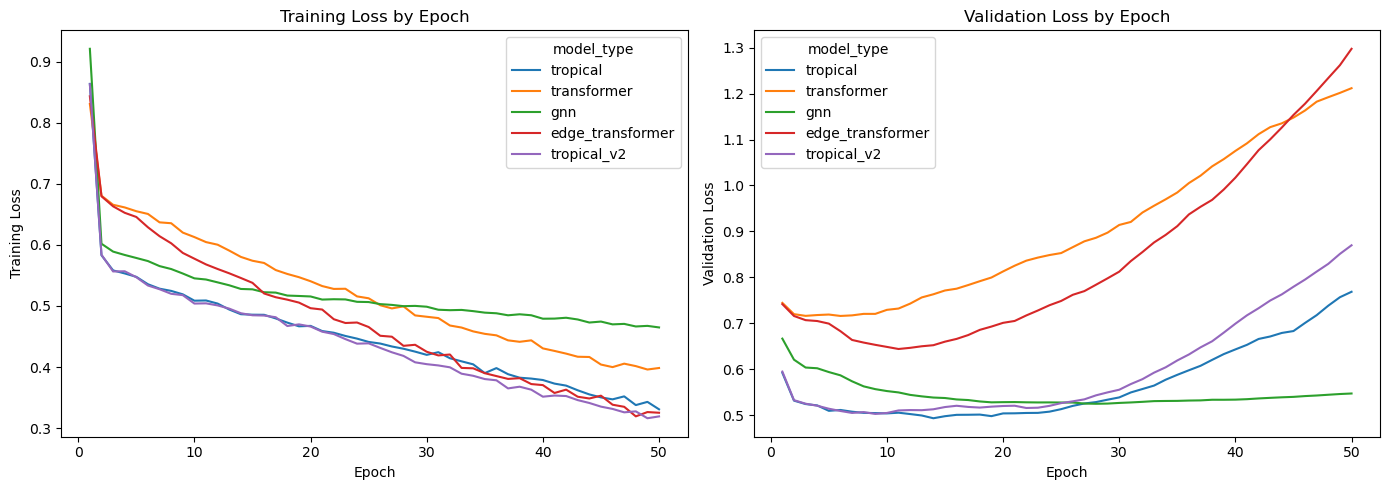

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.lineplot(
    data=df_all,
    x="epoch",
    y="train_loss",
    hue="model_type",
    ax=axes[0]
)

axes[0].set_title("Training Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="val_loss",
    hue="model_type",
    ax=axes[1]
)

axes[1].set_title("Validation Loss by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")

plt.tight_layout()
plt.show()

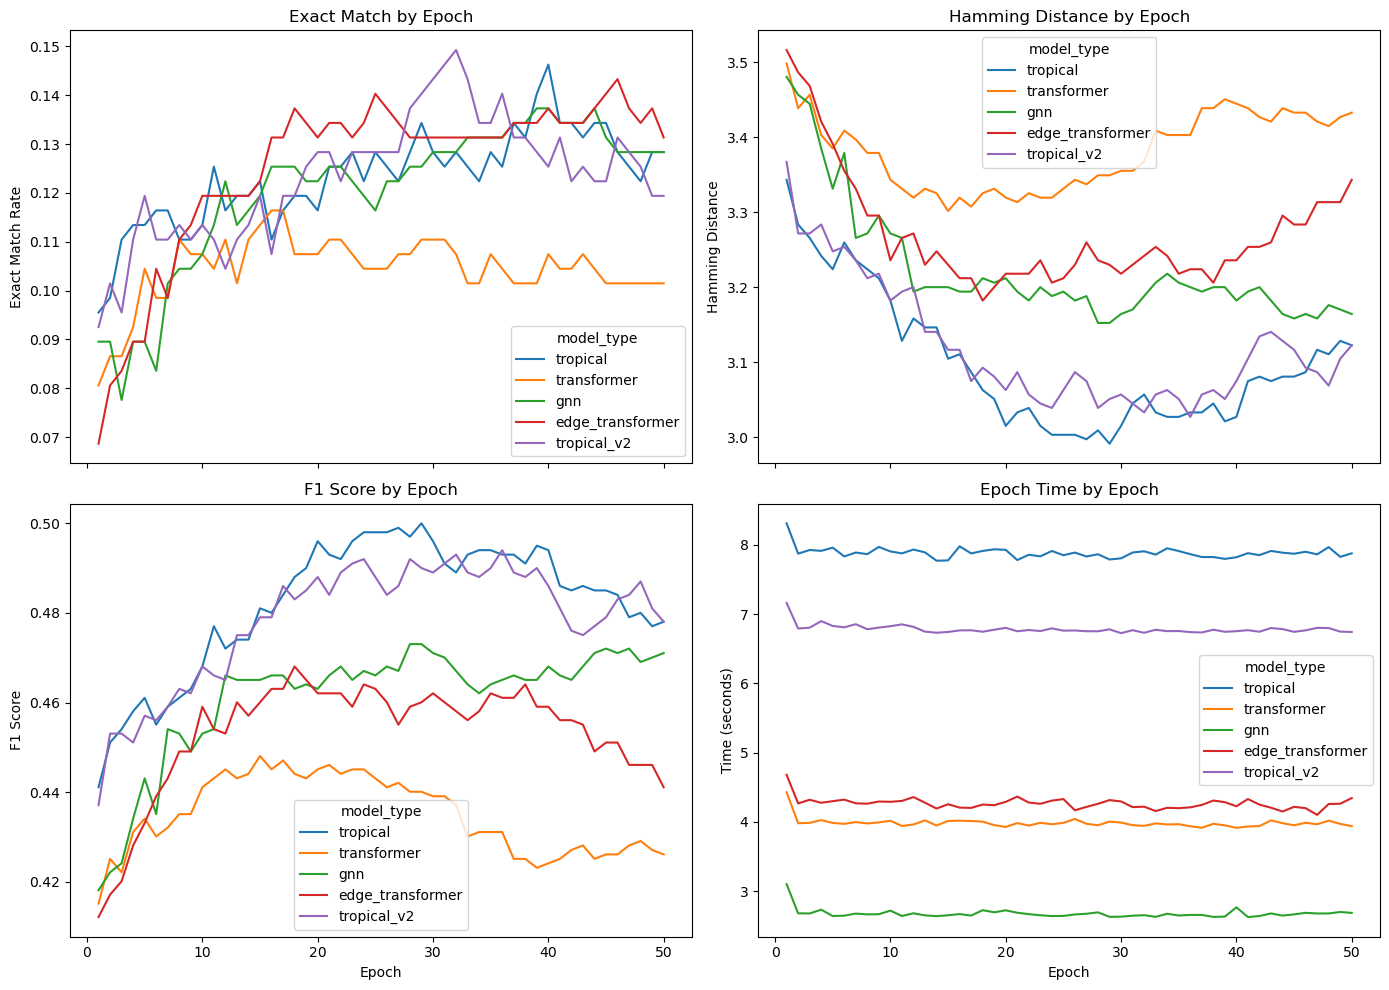

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

sns.lineplot(
    data=df_all,
    x="epoch",
    y="exact_match",
    hue="model_type",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Exact Match by Epoch")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Exact Match Rate")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="hamming",
    hue="model_type",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Hamming Distance by Epoch")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Hamming Distance")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="f1",
    hue="model_type",
    ax=axes[1, 0]
)
axes[1, 0].set_title("F1 Score by Epoch")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("F1 Score")

sns.lineplot(
    data=df_all,
    x="epoch",
    y="epoch_time_seconds",
    hue="model_type",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Epoch Time by Epoch")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [25]:
df_tropical_eval = pd.read_csv('evaluation_results_tropical_shortest_path_ood_size.csv')
df_tropical_eval.head()

,model_type,problem_type,eval_mode,graph_seed,n_nodes,n_edges,density,replication,attack_limit,optimal_objective,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,tropical,shortest_path,ood_size,10025005,100,250,2.5,0,1,13.0,13,0.000000,0,1,1,1,1,0.060277,0.085241,0.174395
1,tropical,shortest_path,ood_size,10025006,100,250,2.5,1,1,33.0,31,0.060606,2,0,0,1,1,0.066001,0.071820,0.002440
2,tropical,shortest_path,ood_size,10025007,100,250,2.5,2,1,22.0,22,0.000000,0,1,1,1,1,0.051375,0.057019,0.002398
3,tropical,shortest_path,ood_size,10025008,100,250,2.5,3,1,20.0,20,0.000000,0,1,1,1,1,0.075770,0.081374,0.002488
4,tropical,shortest_path,ood_size,10025009,100,250,2.5,4,1,34.0,27,0.205882,2,0,0,1,1,0.050510,0.056195,0.002334


In [27]:
df_transformer_eval = pd.read_csv('evaluation_results_transformer_shortest_path_ood_size.csv')
df_transformer_eval.head() 

,model_type,problem_type,eval_mode,graph_seed,n_nodes,n_edges,density,replication,attack_limit,optimal_objective,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,transformer,shortest_path,ood_size,10025005,100,250,2.5,0,1,13.0,13,0.000000,0,1,1,1,1,0.036968,0.061521,0.201335
1,transformer,shortest_path,ood_size,10025006,100,250,2.5,1,1,33.0,31,0.060606,2,0,0,1,1,0.064750,0.070481,0.002417
2,transformer,shortest_path,ood_size,10025007,100,250,2.5,2,1,22.0,20,0.090909,2,0,0,1,1,0.051027,0.056855,0.002395
3,transformer,shortest_path,ood_size,10025008,100,250,2.5,3,1,20.0,20,0.000000,0,1,1,1,1,0.073899,0.079521,0.002369
4,transformer,shortest_path,ood_size,10025009,100,250,2.5,4,1,34.0,27,0.205882,2,0,0,1,1,0.051940,0.057620,0.002480


In [29]:
df_edge_eval = pd.read_csv('evaluation_results_edge_transformer_shortest_path_ood_size.csv')
df_edge_eval.head() 

,model_type,problem_type,eval_mode,graph_seed,n_nodes,n_edges,density,replication,attack_limit,optimal_objective,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,edge_transformer,shortest_path,ood_size,10025005,100,250,2.5,0,1,13.0,13,0.000000,0,1,1,1,1,0.036474,0.060833,0.163825
1,edge_transformer,shortest_path,ood_size,10025006,100,250,2.5,1,1,33.0,31,0.060606,2,0,0,1,1,0.065042,0.070935,0.001881
2,edge_transformer,shortest_path,ood_size,10025007,100,250,2.5,2,1,22.0,20,0.090909,2,0,0,1,1,0.051076,0.056766,0.001859
3,edge_transformer,shortest_path,ood_size,10025008,100,250,2.5,3,1,20.0,20,0.000000,0,1,1,1,1,0.074548,0.080331,0.001860
4,edge_transformer,shortest_path,ood_size,10025009,100,250,2.5,4,1,34.0,27,0.205882,2,0,0,1,1,0.051975,0.057759,0.001955


In [35]:
df_gnn_eval = pd.read_csv('evaluation_results_gnn_shortest_path_ood_size.csv')
df_gnn_eval.head() 

,model_type,problem_type,eval_mode,graph_seed,n_nodes,n_edges,density,replication,attack_limit,optimal_objective,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,gnn,shortest_path,ood_size,10025005,100,250,2.5,0,1,13.0,13,0.000000,0,1,1,1,1,0.038449,0.064245,0.172733
1,gnn,shortest_path,ood_size,10025006,100,250,2.5,1,1,33.0,26,0.212121,2,0,0,1,1,0.065854,0.071651,0.001135
2,gnn,shortest_path,ood_size,10025007,100,250,2.5,2,1,22.0,20,0.090909,2,0,0,1,1,0.051921,0.057752,0.001077
3,gnn,shortest_path,ood_size,10025008,100,250,2.5,3,1,20.0,20,0.000000,0,1,1,1,1,0.074682,0.080434,0.001065
4,gnn,shortest_path,ood_size,10025009,100,250,2.5,4,1,34.0,27,0.205882,2,0,0,1,1,0.052724,0.058436,0.001142


In [33]:
df_tropical_fast_eval = pd.read_csv('evaluation_results_tropical_v2_shortest_path_ood_size.csv')
df_tropical_fast_eval.head()

,model_type,problem_type,eval_mode,graph_seed,n_nodes,n_edges,density,replication,attack_limit,optimal_objective,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,tropical_v2,shortest_path,ood_size,10025005,100,250,2.5,0,1,13.0,13,0.000000,0,1,1,1,1,0.037405,0.062779,0.568430
1,tropical_v2,shortest_path,ood_size,10025006,100,250,2.5,1,1,33.0,31,0.060606,2,0,0,1,1,0.065652,0.071705,0.005823
2,tropical_v2,shortest_path,ood_size,10025007,100,250,2.5,2,1,22.0,20,0.090909,2,0,0,1,1,0.051962,0.057554,0.005739
3,tropical_v2,shortest_path,ood_size,10025008,100,250,2.5,3,1,20.0,20,0.000000,0,1,1,1,1,0.074330,0.080087,0.005693
4,tropical_v2,shortest_path,ood_size,10025009,100,250,2.5,4,1,34.0,27,0.205882,2,0,0,1,1,0.050538,0.056356,0.005654


In [37]:
df_tropical_eval["model_type"] = "tropical"
df_transformer_eval["model_type"] = "transformer"
df_gnn_eval["model_type"] = "gnn"
df_edge_eval["model_type"] = "edge_transformer"
df_tropical_fast_eval["model_type"] = "tropical_v2"

df_all_eval = pd.concat(
    [df_tropical_eval, df_transformer_eval, df_gnn_eval, df_edge_eval,df_tropical_fast_eval],
    ignore_index=True
)

df_all_eval

,model_type,problem_type,eval_mode,graph_seed,n_nodes,n_edges,density,replication,attack_limit,optimal_objective,predicted_objective,objective_gap,hamming_distance,exact_match,num_correct_edges,num_predicted_attacks,num_optimal_attacks,mip_solve_time,mip_total_time,inference_time
0,tropical,shortest_path,ood_size,10025005,100,250,2.5,0,1,13.0,13,0.000000,0,1,1,1,1,0.060277,0.085241,0.174395
1,tropical,shortest_path,ood_size,10025006,100,250,2.5,1,1,33.0,31,0.060606,2,0,0,1,1,0.066001,0.071820,0.002440
2,tropical,shortest_path,ood_size,10025007,100,250,2.5,2,1,22.0,22,0.000000,0,1,1,1,1,0.051375,0.057019,0.002398
3,tropical,shortest_path,ood_size,10025008,100,250,2.5,3,1,20.0,20,0.000000,0,1,1,1,1,0.075770,0.081374,0.002488
4,tropical,shortest_path,ood_size,10025009,100,250,2.5,4,1,34.0,27,0.205882,2,0,0,1,1,0.050510,0.056195,0.002334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,tropical_v2,shortest_path,ood_size,40160020,400,1600,4.0,15,5,33.0,23,0.303030,4,0,3,5,5,0.237055,0.269031,0.011109
4996,tropical_v2,shortest_path,ood_size,40160021,400,1600,4.0,16,5,35.0,30,0.142857,4,0,3,5,5,1.201271,1.233124,0.011102
4997,tropical_v2,shortest_path,ood_size,40160022,400,1600,4.0,17,5,26.0,18,0.307692,4,0,3,5,5,0.734152,0.766156,0.011104
4998,tropical_v2,shortest_path,ood_size,40160023,400,1600,4.0,18,5,30.0,27,0.100000,6,0,2,5,5,2.012129,2.045069,0.011206


In [39]:
summary = (
    df_all_eval.groupby(["model_type", "attack_limit"])
      .agg(
          exact_match_avg=("exact_match", "mean"),
          objective_gap_avg=("objective_gap", "mean"),
          objective_gap_median=("objective_gap", "median"),
          objective_gap_std=("objective_gap", "std"),
          hamming_distance_avg=("hamming_distance", "mean"),
          inference_time_avg=("inference_time", "mean"),
          mip_solve_time_avg=("mip_solve_time", "mean"),
      )
      .reset_index()
)

summary

,model_type,attack_limit,exact_match_avg,objective_gap_avg,objective_gap_median,objective_gap_std,hamming_distance_avg,inference_time_avg,mip_solve_time_avg
0,edge_transformer,1,0.245,0.103560,0.071429,0.115890,1.510,0.002874,0.255172
1,edge_transformer,2,0.095,0.149913,0.137147,0.118855,2.635,0.002024,0.250791
2,edge_transformer,3,0.055,0.160552,0.153010,0.113371,3.395,0.002033,0.395143
3,edge_transformer,4,0.010,0.165291,0.161002,0.106273,4.350,0.002035,0.469270
4,edge_transformer,5,0.005,0.173614,0.174603,0.106223,5.500,0.002030,0.567534
5,gnn,1,0.265,0.100423,0.075499,0.105643,1.470,0.002001,0.251009
6,gnn,2,0.115,0.147215,0.142857,0.123775,2.525,0.001114,0.250316
7,gnn,3,0.055,0.155966,0.142857,0.122748,3.275,0.001121,0.388987
8,gnn,4,0.020,0.166404,0.153846,0.118093,4.240,0.001120,0.476586
9,gnn,5,0.000,0.169359,0.147300,0.113958,5.330,0.001116,0.577451


In [41]:
df_summary = summary.sort_values(by="objective_gap_median")
df_summary

,model_type,attack_limit,exact_match_avg,objective_gap_avg,objective_gap_median,objective_gap_std,hamming_distance_avg,inference_time_avg,mip_solve_time_avg
15,tropical,1,0.290,0.095860,0.058824,0.111808,1.420,0.008534,0.247814
0,edge_transformer,1,0.245,0.103560,0.071429,0.115890,1.510,0.002874,0.255172
20,tropical_v2,1,0.265,0.103729,0.071429,0.118082,1.470,0.009582,0.259268
5,gnn,1,0.265,0.100423,0.075499,0.105643,1.470,0.002001,0.251009
10,transformer,1,0.220,0.118050,0.085145,0.124515,1.560,0.003489,0.253646
16,tropical,2,0.135,0.134982,0.105296,0.123757,2.425,0.007637,0.257692
21,tropical_v2,2,0.120,0.140177,0.115385,0.120872,2.485,0.006712,0.249804
1,edge_transformer,2,0.095,0.149913,0.137147,0.118855,2.635,0.002024,0.250791
6,gnn,2,0.115,0.147215,0.142857,0.123775,2.525,0.001114,0.250316
7,gnn,3,0.055,0.155966,0.142857,0.122748,3.275,0.001121,0.388987


In [43]:
df_summary2 = summary.sort_values(by="objective_gap_avg")
df_summary2

,model_type,attack_limit,exact_match_avg,objective_gap_avg,objective_gap_median,objective_gap_std,hamming_distance_avg,inference_time_avg,mip_solve_time_avg
15,tropical,1,0.290,0.095860,0.058824,0.111808,1.420,0.008534,0.247814
5,gnn,1,0.265,0.100423,0.075499,0.105643,1.470,0.002001,0.251009
0,edge_transformer,1,0.245,0.103560,0.071429,0.115890,1.510,0.002874,0.255172
20,tropical_v2,1,0.265,0.103729,0.071429,0.118082,1.470,0.009582,0.259268
10,transformer,1,0.220,0.118050,0.085145,0.124515,1.560,0.003489,0.253646
16,tropical,2,0.135,0.134982,0.105296,0.123757,2.425,0.007637,0.257692
21,tropical_v2,2,0.120,0.140177,0.115385,0.120872,2.485,0.006712,0.249804
6,gnn,2,0.115,0.147215,0.142857,0.123775,2.525,0.001114,0.250316
1,edge_transformer,2,0.095,0.149913,0.137147,0.118855,2.635,0.002024,0.250791
11,transformer,2,0.085,0.151586,0.142857,0.122203,2.645,0.002511,0.249277


In [45]:
summary = (
    df_all_eval.groupby(["model_type", "density"])
      .agg(
          exact_match_avg=("exact_match", "mean"),
          objective_gap_avg=("objective_gap", "mean"),
          objective_gap_median=("objective_gap", "median"),
          objective_gap_std=("objective_gap", "std"),
          hamming_distance_avg=("hamming_distance", "mean"),
          inference_time_avg=("inference_time", "mean"),
          mip_solve_time_avg=("mip_solve_time", "mean"),
      )
      .reset_index()
)

summary

,model_type,density,exact_match_avg,objective_gap_avg,objective_gap_median,objective_gap_std,hamming_distance_avg,inference_time_avg,mip_solve_time_avg
0,edge_transformer,2.5,0.102,0.146286,0.142857,0.110918,3.438,0.002239,0.280407
1,edge_transformer,4.0,0.062,0.154886,0.142857,0.118342,3.518,0.002160,0.494757
2,gnn,2.5,0.108,0.144468,0.134234,0.116583,3.338,0.001450,0.281578
3,gnn,4.0,0.074,0.151279,0.134848,0.122255,3.398,0.001139,0.496161
4,transformer,2.5,0.088,0.153099,0.150000,0.110106,3.498,0.002853,0.280105
5,transformer,4.0,0.058,0.165791,0.148148,0.128122,3.534,0.002537,0.494162
6,tropical,2.5,0.124,0.135940,0.133333,0.114094,3.246,0.005182,0.285951
7,tropical,4.0,0.078,0.147694,0.130435,0.118085,3.362,0.010452,0.493654
8,tropical_v2,2.5,0.106,0.139407,0.125000,0.113782,3.278,0.007173,0.281731
9,tropical_v2,4.0,0.084,0.150094,0.135749,0.118993,3.374,0.007448,0.496258


In [ ]:
df_all_eval

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_DIR = "results/figures/ood_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results_df = df_all_eval.copy()

# More readable model labels.
model_labels = {
    "tropical": "Tropical V1",
    "tropical_v2": "Tropical V2",
    "transformer": "Transformer",
    "edge_transformer": "Edge-Bias Transformer",
    "gnn": "GNN",
}

results_df["model_label"] = (
    results_df["model_type"]
    .map(model_labels)
    .fillna(results_df["model_type"])
)

preferred_order = [
    "Tropical V1",
    "Tropical V2",
    "Transformer",
    "Edge-Bias Transformer",
    "GNN",
]

model_order = [
    model
    for model in preferred_order
    if model in results_df["model_label"].unique()
]

# Derived metrics.
results_df["normalized_hamming"] = (
    results_df["hamming_distance"]
    / (2 * results_df["attack_limit"])
)

results_df["edge_recovery_rate"] = (
    results_df["num_correct_edges"]
    / results_df["num_optimal_attacks"]
)

results_df["within_5_percent"] = (
    results_df["objective_gap"] <= 0.05
).astype(int)

results_df["within_10_percent"] = (
    results_df["objective_gap"] <= 0.10
).astype(int)

results_df["within_20_percent"] = (
    results_df["objective_gap"] <= 0.20
).astype(int)


def save_plot(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")

In [41]:
def plot_objective_gap_distribution_grid(
    data,
    show_outliers=False,
):
    for n_nodes in sorted(data["n_nodes"].unique()):
        size_df = data[data["n_nodes"] == n_nodes].copy()

        grid = sns.catplot(
            data=size_df,
            x="model_label",
            y="objective_gap",
            row="density",
            col="attack_limit",
            kind="box",
            order=model_order,
            showfliers=show_outliers,
            sharey=True,
            height=3.2,
            aspect=1.15,
            margin_titles=True,
        )

        grid.set_axis_labels(
            "",
            "Objective Gap",
        )

        grid.set_titles(
            row_template="Density = {row_name}",
            col_template="Attack Budget = {col_name}",
        )

        for axis in grid.axes.flat:
            axis.tick_params(
                axis="x",
                labelrotation=45,
            )

            for label in axis.get_xticklabels():
                label.set_horizontalalignment("right")

        grid.figure.suptitle(
            f"Objective Gap Distributions: {n_nodes} Nodes",
            y=1.02,
        )

        grid.figure.subplots_adjust(
            top=0.91,
            hspace=0.25,
            wspace=0.12,
        )

        path = os.path.join(
            OUTPUT_DIR,
            f"objective_gap_grid_{n_nodes}_nodes.png",
        )

        grid.figure.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.close(grid.figure)
        print(f"Saved: {path}")


plot_objective_gap_distribution_grid(results_df)

Saved: results/figures/ood_analysis\objective_gap_grid_100_nodes.png
Saved: results/figures/ood_analysis\objective_gap_grid_150_nodes.png
Saved: results/figures/ood_analysis\objective_gap_grid_200_nodes.png
Saved: results/figures/ood_analysis\objective_gap_grid_300_nodes.png
Saved: results/figures/ood_analysis\objective_gap_grid_400_nodes.png


In [43]:
def plot_objective_gap_quantile_curves(data):
    for n_nodes in sorted(data["n_nodes"].unique()):
        size_df = data[data["n_nodes"] == n_nodes].copy()

        attack_budgets = sorted(
            size_df["attack_limit"].unique()
        )

        fig, axes = plt.subplots(
            nrows=1,
            ncols=len(attack_budgets),
            figsize=(5 * len(attack_budgets), 5),
            sharey=True,
        )

        if len(attack_budgets) == 1:
            axes = [axes]

        for axis, attack_limit in zip(
            axes,
            attack_budgets,
        ):
            attack_df = size_df[
                size_df["attack_limit"] == attack_limit
            ]

            for model in model_order:
                model_df = attack_df[
                    attack_df["model_label"] == model
                ]

                summary = (
                    model_df
                    .groupby("density")["objective_gap"]
                    .agg(
                        median="median",
                        q25=lambda x: x.quantile(0.25),
                        q75=lambda x: x.quantile(0.75),
                        q10=lambda x: x.quantile(0.10),
                        q90=lambda x: x.quantile(0.90),
                    )
                    .reset_index()
                    .sort_values("density")
                )

                if summary.empty:
                    continue

                line = axis.plot(
                    summary["density"],
                    summary["median"],
                    marker="o",
                    label=model,
                )[0]

                # Interquartile range.
                axis.fill_between(
                    summary["density"],
                    summary["q25"],
                    summary["q75"],
                    alpha=0.20,
                    color=line.get_color(),
                )

                # Optional 10th–90th percentile bounds.
                axis.plot(
                    summary["density"],
                    summary["q10"],
                    linestyle=":",
                    alpha=0.6,
                    color=line.get_color(),
                )

                axis.plot(
                    summary["density"],
                    summary["q90"],
                    linestyle=":",
                    alpha=0.6,
                    color=line.get_color(),
                )

            axis.set_title(
                f"Attack Budget = {attack_limit}"
            )
            axis.set_xlabel("Graph Density")
            axis.grid(alpha=0.3)

        axes[0].set_ylabel("Objective Gap")

        handles, labels = axes[-1].get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            title="Model",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.06),
            ncol=min(len(model_order), 5),
        )

        fig.suptitle(
            f"Objective Gap by Density: {n_nodes} Nodes",
            y=1.15,
        )

        fig.tight_layout()

        path = os.path.join(
            OUTPUT_DIR,
            f"objective_gap_quantiles_{n_nodes}_nodes.png",
        )

        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.close(fig)
        print(f"Saved: {path}")


plot_objective_gap_quantile_curves(results_df)

Saved: results/figures/ood_analysis\objective_gap_quantiles_100_nodes.png
Saved: results/figures/ood_analysis\objective_gap_quantiles_150_nodes.png
Saved: results/figures/ood_analysis\objective_gap_quantiles_200_nodes.png
Saved: results/figures/ood_analysis\objective_gap_quantiles_300_nodes.png
Saved: results/figures/ood_analysis\objective_gap_quantiles_400_nodes.png


In [49]:
def plot_metric_heatmaps(
    data,
    metric,
    aggregation,
    title,
    colorbar_label,
    filename_prefix,
    value_format=".3f",
    vmin=None,
    vmax=None,
):
    for n_nodes in sorted(data["n_nodes"].unique()):
        size_df = data[
            data["n_nodes"] == n_nodes
        ].copy()

        models = [
            model
            for model in model_order
            if model in size_df["model_label"].unique()
        ]

        if len(models) == 0:
            continue

        fig, axes = plt.subplots(
            nrows=1,
            ncols=len(models),
            figsize=(5 * len(models), 5),
            sharex=True,
            sharey=True,
        )

        # plt.subplots returns one Axes object rather than an
        # array when only one model is present.
        if len(models) == 1:
            axes = [axes]

        pivots = {}

        for model in models:
            model_df = size_df[
                size_df["model_label"] == model
            ].copy()

            if callable(aggregation):
                grouped = (
                    model_df
                    .groupby(
                        ["density", "attack_limit"]
                    )[metric]
                    .apply(aggregation)
                    .reset_index(name="value")
                )

            else:
                grouped = (
                    model_df
                    .groupby(
                        ["density", "attack_limit"],
                        as_index=False,
                    )[metric]
                    .agg(aggregation)
                    .rename(
                        columns={metric: "value"}
                    )
                )

            pivot = grouped.pivot(
                index="density",
                columns="attack_limit",
                values="value",
            )

            pivot = (
                pivot
                .sort_index()
                .sort_index(axis=1)
            )

            pivots[model] = pivot

        # Use the same color scale across every model panel.
        all_values = np.concatenate(
            [
                pivot.to_numpy().ravel()
                for pivot in pivots.values()
            ]
        )

        all_values = all_values[
            np.isfinite(all_values)
        ]

        if len(all_values) == 0:
            plt.close(fig)
            continue

        shared_vmin = (
            vmin
            if vmin is not None
            else all_values.min()
        )

        shared_vmax = (
            vmax
            if vmax is not None
            else all_values.max()
        )

        for i, (axis, model) in enumerate(
            zip(axes, models)
        ):
            show_colorbar = i == len(models) - 1

            sns.heatmap(
                pivots[model],
                annot=True,
                fmt=value_format,
                cmap="viridis",
                vmin=shared_vmin,
                vmax=shared_vmax,
                cbar=show_colorbar,
                cbar_kws=(
                    {"label": colorbar_label}
                    if show_colorbar
                    else None
                ),
                ax=axis,  # Correct argument name
            )

            axis.set_title(model)
            axis.set_xlabel("Attack Budget")

            if i == 0:
                axis.set_ylabel("Graph Density")
            else:
                axis.set_ylabel("")

        fig.suptitle(
            f"{title}: {n_nodes} Nodes",
            y=1.03,
        )

        fig.tight_layout()

        path = os.path.join(
            OUTPUT_DIR,
            f"{filename_prefix}_{n_nodes}_nodes.png",
        )

        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.close(fig)
        print(f"Saved: {path}")

In [51]:
plot_metric_heatmaps(
    data=results_df,
    metric="objective_gap",
    aggregation="median",
    title="Median Objective Gap",
    colorbar_label="Median Objective Gap",
    filename_prefix="median_objective_gap_heatmap",
    value_format=".3f",
    vmin=0,
)

Saved: results/figures/ood_analysis\median_objective_gap_heatmap_100_nodes.png
Saved: results/figures/ood_analysis\median_objective_gap_heatmap_150_nodes.png
Saved: results/figures/ood_analysis\median_objective_gap_heatmap_200_nodes.png
Saved: results/figures/ood_analysis\median_objective_gap_heatmap_300_nodes.png
Saved: results/figures/ood_analysis\median_objective_gap_heatmap_400_nodes.png


In [53]:
plot_metric_heatmaps(
    data=results_df,
    metric="objective_gap",
    aggregation=lambda x: x.quantile(0.90),
    title="90th-Percentile Objective Gap",
    colorbar_label="90th-Percentile Gap",
    filename_prefix="p90_objective_gap_heatmap",
    value_format=".3f",
    vmin=0,
)

Saved: results/figures/ood_analysis\p90_objective_gap_heatmap_100_nodes.png
Saved: results/figures/ood_analysis\p90_objective_gap_heatmap_150_nodes.png
Saved: results/figures/ood_analysis\p90_objective_gap_heatmap_200_nodes.png
Saved: results/figures/ood_analysis\p90_objective_gap_heatmap_300_nodes.png
Saved: results/figures/ood_analysis\p90_objective_gap_heatmap_400_nodes.png


In [55]:
plot_metric_heatmaps(
    data=results_df,
    metric="exact_match",
    aggregation="mean",
    title="Exact-Match Rate",
    colorbar_label="Proportion Exact Match",
    filename_prefix="exact_match_heatmap",
    value_format=".2f",
    vmin=0,
    vmax=1,
)

Saved: results/figures/ood_analysis\exact_match_heatmap_100_nodes.png
Saved: results/figures/ood_analysis\exact_match_heatmap_150_nodes.png
Saved: results/figures/ood_analysis\exact_match_heatmap_200_nodes.png
Saved: results/figures/ood_analysis\exact_match_heatmap_300_nodes.png
Saved: results/figures/ood_analysis\exact_match_heatmap_400_nodes.png


In [57]:
plot_metric_heatmaps(
    data=results_df,
    metric="normalized_hamming",
    aggregation="median",
    title="Median Normalized Hamming Distance",
    colorbar_label="Normalized Hamming Distance",
    filename_prefix="normalized_hamming_heatmap",
    value_format=".2f",
    vmin=0,
    vmax=1,
)

Saved: results/figures/ood_analysis\normalized_hamming_heatmap_100_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_150_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_200_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_300_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_400_nodes.png


In [59]:
plot_metric_heatmaps(
    data=results_df,
    metric="normalized_hamming",
    aggregation="median",
    title="Median Normalized Hamming Distance",
    colorbar_label="Normalized Hamming Distance",
    filename_prefix="normalized_hamming_heatmap",
    value_format=".2f",
    vmin=0,
    vmax=1,
)

Saved: results/figures/ood_analysis\normalized_hamming_heatmap_100_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_150_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_200_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_300_nodes.png
Saved: results/figures/ood_analysis\normalized_hamming_heatmap_400_nodes.png


In [61]:
plot_metric_heatmaps(
    data=results_df,
    metric="within_10_percent",
    aggregation="mean",
    title="Proportion Within 10% of Optimal",
    colorbar_label="Proportion Within 10%",
    filename_prefix="within_10_percent_heatmap",
    value_format=".2f",
    vmin=0,
    vmax=1,
)

Saved: results/figures/ood_analysis\within_10_percent_heatmap_100_nodes.png
Saved: results/figures/ood_analysis\within_10_percent_heatmap_150_nodes.png
Saved: results/figures/ood_analysis\within_10_percent_heatmap_200_nodes.png
Saved: results/figures/ood_analysis\within_10_percent_heatmap_300_nodes.png
Saved: results/figures/ood_analysis\within_10_percent_heatmap_400_nodes.png


In [63]:
instance_columns = [
    "n_nodes",
    "n_edges",
    "density",
    "replication",
    "attack_limit",
]

gap_wide = results_df.pivot_table(
    index=instance_columns,
    columns="model_label",
    values="objective_gap",
    aggfunc="first",
).reset_index()

print(gap_wide.head())

model_label  n_nodes  n_edges  density  replication  attack_limit  \
0                100      250      2.5            0             1   
1                100      250      2.5            0             2   
2                100      250      2.5            0             3   
3                100      250      2.5            0             4   
4                100      250      2.5            0             5   

model_label  Edge-Bias Transformer       GNN  Transformer  Tropical V1  \
0                         0.000000  0.000000     0.000000     0.000000   
1                         0.125000  0.125000     0.125000     0.000000   
2                         0.185185  0.074074     0.185185     0.074074   
3                         0.266667  0.166667     0.266667     0.133333   
4                         0.323077  0.230769     0.323077     0.200000   

model_label  Tropical V2  
0               0.000000  
1               0.125000  
2               0.074074  
3               0.166667  
4    

In [65]:
def add_unique_winner(row, models):
    values = row[models].dropna()

    if values.empty:
        return np.nan

    minimum = values.min()
    winners = values[
        np.isclose(values, minimum)
    ].index.tolist()

    if len(winners) == 1:
        return winners[0]

    return "Tie"


gap_wide["winner"] = gap_wide.apply(
    add_unique_winner,
    axis=1,
    models=model_order,
)

In [67]:
def plot_model_win_rate_heatmaps(gap_wide):
    for n_nodes in sorted(gap_wide["n_nodes"].unique()):
        size_df = gap_wide[
            gap_wide["n_nodes"] == n_nodes
        ].copy()

        models = [
            model
            for model in model_order
            if model in gap_wide.columns
        ]

        fig, axes = plt.subplots(
            nrows=1,
            ncols=len(models),
            figsize=(5 * len(models), 5),
            sharex=True,
            sharey=True,
        )

        if len(models) == 1:
            axes = [axes]

        for axis, model in zip(axes, models):
            model_win = (
                size_df
                .assign(
                    model_won=(
                        size_df["winner"] == model
                    ).astype(int)
                )
                .groupby(
                    ["density", "attack_limit"]
                )["model_won"]
                .mean()
                .reset_index()
            )

            pivot = model_win.pivot(
                index="density",
                columns="attack_limit",
                values="model_won",
            )

            sns.heatmap(
                pivot,
                annot=True,
                fmt=".2f",
                cmap="viridis",
                vmin=0,
                vmax=1,
                cbar=axis is axes[-1],
                cbar_kws={
                    "label": "Proportion of Unique Wins"
                } if axis is axes[-1] else None,
                ax=axis,
            )

            axis.set_title(model)
            axis.set_xlabel("Attack Budget")

            if axis is axes[0]:
                axis.set_ylabel("Graph Density")
            else:
                axis.set_ylabel("")

        fig.suptitle(
            f"Unique Model Win Rates: {n_nodes} Nodes",
            y=1.03,
        )

        fig.tight_layout()

        path = os.path.join(
            OUTPUT_DIR,
            f"model_win_rates_{n_nodes}_nodes.png",
        )

        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.close(fig)
        print(f"Saved: {path}")


plot_model_win_rate_heatmaps(gap_wide)

Saved: results/figures/ood_analysis\model_win_rates_100_nodes.png
Saved: results/figures/ood_analysis\model_win_rates_150_nodes.png
Saved: results/figures/ood_analysis\model_win_rates_200_nodes.png
Saved: results/figures/ood_analysis\model_win_rates_300_nodes.png
Saved: results/figures/ood_analysis\model_win_rates_400_nodes.png


In [ ]:
def plot_tie_rate_heatmap(gap_wide):
    for n_nodes in sorted(gap_wide["n_nodes"].unique()):
        size_df = gap_wide[
            gap_wide["n_nodes"] == n_nodes
        ].copy()

        tie_summary = (
            size_df
            .assign(
                tied=(
                    size_df["winner"] == "Tie"
                ).astype(int)
            )
            .groupby(
                ["density", "attack_limit"]
            )["tied"]
            .mean()
            .reset_index()
        )

        pivot = tie_summary.pivot(
            index="density",
            columns="attack_limit",
            values="tied",
        )

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            vmin=0,
            vmax=1,
            cbar_kws={
                "label": "Proportion of Tied Instances"
            },
        )

        plt.xlabel("Attack Budget")
        plt.ylabel("Graph Density")
        plt.title(
            f"Model Tie Rate: {n_nodes} Nodes"
        )

        save_plot(
            f"tie_rate_{n_nodes}_nodes.png"
        )


plot_tie_rate_heatmap(gap_wide)

In [71]:
def plot_pairwise_difference_heatmaps(
    gap_wide,
    reference_model="Tropical V1",
):
    baseline_models = [
        model
        for model in model_order
        if model != reference_model
        and model in gap_wide.columns
    ]

    for n_nodes in sorted(gap_wide["n_nodes"].unique()):
        size_df = gap_wide[
            gap_wide["n_nodes"] == n_nodes
        ].copy()

        fig, axes = plt.subplots(
            nrows=1,
            ncols=len(baseline_models),
            figsize=(5 * len(baseline_models), 5),
            sharex=True,
            sharey=True,
        )

        if len(baseline_models) == 1:
            axes = [axes]

        # Determine common symmetric scale.
        maximum_absolute_difference = 0
        pivot_tables = {}

        for baseline in baseline_models:
            comparison_df = size_df.copy()

            comparison_df["paired_difference"] = (
                comparison_df[reference_model]
                - comparison_df[baseline]
            )

            summary = (
                comparison_df
                .groupby(
                    ["density", "attack_limit"]
                )["paired_difference"]
                .median()
                .reset_index()
            )

            pivot = summary.pivot(
                index="density",
                columns="attack_limit",
                values="paired_difference",
            )

            pivot_tables[baseline] = pivot

            maximum_absolute_difference = max(
                maximum_absolute_difference,
                np.nanmax(
                    np.abs(pivot.values)
                ),
            )

        for axis, baseline in zip(
            axes,
            baseline_models,
        ):
            sns.heatmap(
                pivot_tables[baseline],
                annot=True,
                fmt=".3f",
                cmap="coolwarm",
                center=0,
                vmin=-maximum_absolute_difference,
                vmax=maximum_absolute_difference,
                cbar=axis is axes[-1],
                cbar_kws={
                    "label": (
                        f"{reference_model} Gap "
                        f"− Baseline Gap"
                    )
                } if axis is axes[-1] else None,
                ax=axis,
            )

            axis.set_title(
                f"{reference_model}\nvs. {baseline}"
            )

            axis.set_xlabel("Attack Budget")

            if axis is axes[0]:
                axis.set_ylabel("Graph Density")
            else:
                axis.set_ylabel("")

        fig.suptitle(
            (
                "Median Paired Objective-Gap Difference: "
                f"{n_nodes} Nodes\n"
                "Negative Values Favor Tropical V1"
            ),
            y=1.08,
        )

        fig.tight_layout()

        path = os.path.join(
            OUTPUT_DIR,
            f"paired_gap_difference_{n_nodes}_nodes.png",
        )

        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.close(fig)
        print(f"Saved: {path}")


plot_pairwise_difference_heatmaps(gap_wide)

Saved: results/figures/ood_analysis\paired_gap_difference_100_nodes.png
Saved: results/figures/ood_analysis\paired_gap_difference_150_nodes.png
Saved: results/figures/ood_analysis\paired_gap_difference_200_nodes.png
Saved: results/figures/ood_analysis\paired_gap_difference_300_nodes.png
Saved: results/figures/ood_analysis\paired_gap_difference_400_nodes.png


In [75]:
def plot_pairwise_win_probability_heatmaps(
    gap_wide,
    reference_model="Tropical V1",
):
    baseline_models = [
        model
        for model in model_order
        if model != reference_model
        and model in gap_wide.columns
    ]

    for n_nodes in sorted(gap_wide["n_nodes"].unique()):
        size_df = gap_wide[
            gap_wide["n_nodes"] == n_nodes
        ].copy()

        fig, axes = plt.subplots(
            nrows=1,
            ncols=len(baseline_models),
            figsize=(5 * len(baseline_models), 5),
            sharex=True,
            sharey=True,
        )

        if len(baseline_models) == 1:
            axes = [axes]

        for axis, baseline in zip(
            axes,
            baseline_models,
        ):
            comparison_df = size_df.dropna(
                subset=[
                    reference_model,
                    baseline,
                ]
            ).copy()

            comparison_df["reference_wins"] = (
                comparison_df[reference_model]
                < comparison_df[baseline]
            ).astype(int)

            summary = (
                comparison_df
                .groupby(
                    ["density", "attack_limit"]
                )["reference_wins"]
                .mean()
                .reset_index()
            )

            pivot = summary.pivot(
                index="density",
                columns="attack_limit",
                values="reference_wins",
            )

            sns.heatmap(
                pivot,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                center=0.5,
                vmin=0,
                vmax=1,
                cbar=axis is axes[-1],
                cbar_kws={
                    "label": (
                        f"P({reference_model} Has Lower Gap)"
                    )
                } if axis is axes[-1] else None,
                ax=axis,
            )

            axis.set_title(
                f"{reference_model}\nvs. {baseline}"
            )

            axis.set_xlabel("Attack Budget")

            if axis is axes[0]:
                axis.set_ylabel("Graph Density")
            else:
                axis.set_ylabel("")

        fig.suptitle(
            (
                f"Probability {reference_model} "
                f"Beats Each Baseline: {n_nodes} Nodes"
            ),
            y=1.05,
        )

        fig.tight_layout()

        path = os.path.join(
            OUTPUT_DIR,
            f"pairwise_win_probability_{n_nodes}_nodes.png",
        )

        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.close(fig)
        print(f"Saved: {path}")


plot_pairwise_win_probability_heatmaps(gap_wide)

Saved: results/figures/ood_analysis\pairwise_win_probability_100_nodes.png
Saved: results/figures/ood_analysis\pairwise_win_probability_150_nodes.png
Saved: results/figures/ood_analysis\pairwise_win_probability_200_nodes.png
Saved: results/figures/ood_analysis\pairwise_win_probability_300_nodes.png
Saved: results/figures/ood_analysis\pairwise_win_probability_400_nodes.png


In [77]:
def plot_objective_gap_ecdf(
    data,
    n_nodes,
    density,
    attack_limit,
):
    subset = data[
        (data["n_nodes"] == n_nodes)
        & (data["density"] == density)
        & (data["attack_limit"] == attack_limit)
    ].copy()

    if subset.empty:
        print(
            "No observations found for "
            f"n_nodes={n_nodes}, "
            f"density={density}, "
            f"attack_limit={attack_limit}"
        )
        return

    plt.figure(figsize=(9, 6))

    sns.ecdfplot(
        data=subset,
        x="objective_gap",
        hue="model_label",
        hue_order=model_order,
    )

    plt.axvline(
        0.05,
        linestyle="--",
        alpha=0.7,
        label="5% gap",
    )

    plt.axvline(
        0.10,
        linestyle=":",
        alpha=0.7,
        label="10% gap",
    )

    plt.xlabel("Objective Gap")
    plt.ylabel("Proportion of Instances")
    plt.title(
        "Objective-Gap ECDF\n"
        f"{n_nodes} Nodes, Density {density}, "
        f"Attack Budget {attack_limit}"
    )

    plt.grid(alpha=0.3)

    save_plot(
        (
            f"ecdf_nodes_{n_nodes}_"
            f"density_{density}_"
            f"k_{attack_limit}.png"
        )
    )

In [81]:
plot_objective_gap_ecdf(
    results_df,
    n_nodes=100,
    density=2.5,
    attack_limit=1,
)

plot_objective_gap_ecdf(
    results_df,
    n_nodes=200,
    density=4.0,
    attack_limit=3,
)

plot_objective_gap_ecdf(
    results_df,
    n_nodes=400,
    density=4.0,
    attack_limit=5,
)

Saved: results/figures/ood_analysis\ecdf_nodes_100_density_2.5_k_1.png
Saved: results/figures/ood_analysis\ecdf_nodes_200_density_4.0_k_3.png
Saved: results/figures/ood_analysis\ecdf_nodes_400_density_4.0_k_5.png


In [83]:
def plot_threshold_attainment(
    data,
    n_nodes,
    density,
    attack_limit,
    thresholds=None,
):
    if thresholds is None:
        thresholds = np.linspace(
            0,
            0.50,
            51,
        )

    subset = data[
        (data["n_nodes"] == n_nodes)
        & (data["density"] == density)
        & (data["attack_limit"] == attack_limit)
    ].copy()

    attainment_rows = []

    for model in model_order:
        model_gaps = subset.loc[
            subset["model_label"] == model,
            "objective_gap",
        ].dropna()

        for threshold in thresholds:
            attainment_rows.append(
                {
                    "model_label": model,
                    "threshold": threshold,
                    "proportion": (
                        model_gaps <= threshold
                    ).mean(),
                }
            )

    attainment_df = pd.DataFrame(
        attainment_rows
    )

    plt.figure(figsize=(9, 6))

    sns.lineplot(
        data=attainment_df,
        x="threshold",
        y="proportion",
        hue="model_label",
        hue_order=model_order,
    )

    plt.xlabel("Objective-Gap Threshold")
    plt.ylabel(
        "Proportion of Instances at or Below Threshold"
    )

    plt.title(
        "Objective-Gap Threshold Attainment\n"
        f"{n_nodes} Nodes, Density {density}, "
        f"Attack Budget {attack_limit}"
    )

    plt.ylim(0, 1)
    plt.grid(alpha=0.3)

    save_plot(
        (
            f"threshold_attainment_nodes_{n_nodes}_"
            f"density_{density}_"
            f"k_{attack_limit}.png"
        )
    )

In [85]:
def plot_threshold_attainment(
    data,
    n_nodes,
    density,
    attack_limit,
    thresholds=None,
):
    if thresholds is None:
        thresholds = np.linspace(
            0,
            0.50,
            51,
        )

    subset = data[
        (data["n_nodes"] == n_nodes)
        & (data["density"] == density)
        & (data["attack_limit"] == attack_limit)
    ].copy()

    attainment_rows = []

    for model in model_order:
        model_gaps = subset.loc[
            subset["model_label"] == model,
            "objective_gap",
        ].dropna()

        for threshold in thresholds:
            attainment_rows.append(
                {
                    "model_label": model,
                    "threshold": threshold,
                    "proportion": (
                        model_gaps <= threshold
                    ).mean(),
                }
            )

    attainment_df = pd.DataFrame(
        attainment_rows
    )

    plt.figure(figsize=(9, 6))

    sns.lineplot(
        data=attainment_df,
        x="threshold",
        y="proportion",
        hue="model_label",
        hue_order=model_order,
    )

    plt.xlabel("Objective-Gap Threshold")
    plt.ylabel(
        "Proportion of Instances at or Below Threshold"
    )

    plt.title(
        "Objective-Gap Threshold Attainment\n"
        f"{n_nodes} Nodes, Density {density}, "
        f"Attack Budget {attack_limit}"
    )

    plt.ylim(0, 1)
    plt.grid(alpha=0.3)

    save_plot(
        (
            f"threshold_attainment_nodes_{n_nodes}_"
            f"density_{density}_"
            f"k_{attack_limit}.png"
        )
    )

In [87]:
def plot_inference_runtime_grid(data):
    grid = sns.catplot(
        data=data,
        x="density",
        y="inference_time",
        hue="model_label",
        hue_order=model_order,
        col="n_nodes",
        row="attack_limit",
        kind="box",
        showfliers=False,
        sharey=False,
        height=3.3,
        aspect=1.1,
        margin_titles=True,
    )

    grid.set_axis_labels(
        "Graph Density",
        "Inference Time (seconds)",
    )

    grid.set_titles(
        row_template="Attack Budget = {row_name}",
        col_template="{col_name} Nodes",
    )

    grid.figure.suptitle(
        "Inference-Time Distributions",
        y=1.02,
    )

    grid.figure.subplots_adjust(top=0.93)

    path = os.path.join(
        OUTPUT_DIR,
        "inference_runtime_grid.png",
    )

    grid.figure.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.close(grid.figure)
    print(f"Saved: {path}")


plot_inference_runtime_grid(results_df)

Saved: results/figures/ood_analysis\inference_runtime_grid.png


In [89]:
mip_df = (
    results_df
    .sort_values(instance_columns)
    .drop_duplicates(subset=instance_columns)
    .copy()
)

In [91]:
def plot_mip_runtime_grid(mip_df):
    grid = sns.catplot(
        data=mip_df,
        x="density",
        y="mip_total_time",
        col="n_nodes",
        row="attack_limit",
        kind="box",
        showfliers=False,
        sharey=False,
        height=3.3,
        aspect=1.1,
        margin_titles=True,
    )

    grid.set_axis_labels(
        "Graph Density",
        "MIP Total Time (seconds)",
    )

    grid.set_titles(
        row_template="Attack Budget = {row_name}",
        col_template="{col_name} Nodes",
    )

    grid.figure.suptitle(
        "MIP Runtime Distributions",
        y=1.02,
    )

    grid.figure.subplots_adjust(top=0.93)

    path = os.path.join(
        OUTPUT_DIR,
        "mip_runtime_grid.png",
    )

    grid.figure.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.close(grid.figure)
    print(f"Saved: {path}")


plot_mip_runtime_grid(mip_df)

Saved: results/figures/ood_analysis\mip_runtime_grid.png
